In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import numpy as np
from pytorch_lightning import Trainer, LightningModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from torchvision.models import resnet18, resnet34
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from pytorch_lightning import LightningModule
from torchvision.models import resnet18
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
labels = torch.tensor([1,2,3])
input = torch.rand([3,4, 32, 32])
#model = ResNet18Ensemble(3)
#outputs = model(input)


/home/nh/anaconda3/envs/benchmark_mil/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model = resnet18()
nn.Sequential(*list(model.children())[:-1])

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
import numpy as np
from scipy.stats import entropy
from sklearn.metrics import roc_auc_score

def AULC(accs, uncertainties):
  idxs = np.argsort(uncertainties)
  uncs_s = uncertainties[idxs]
  error_s = accs[idxs]

  mean_error = error_s.mean()
  error_csum = np.cumsum(error_s)

  Fs = error_csum / np.arange(1, len(error_s) + 1)
  s = 1 / len(Fs)
  return -1 + s * Fs.sum() / mean_error, Fs

def rAULC(uncertainties, accs):
    perf_aulc, Fsp = AULC(accs, -accs.astype("float"))
    curr_aulc, Fsc = AULC(accs, uncertainties)
    return curr_aulc / perf_aulc

def calculate_accuracy(y_true, y_pred):
    return (y_true == y_pred).sum()/len(y_true)


def calculate_auc(y_true, y_probs):
    return  roc_auc_score(y_true, y_probs, multi_class='ovr')


def calculate_ece(y_true, y_probs, n_bins=30):

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_probs, bin_edges) - 1

    ece = 0.0
    for i in range(n_bins):
        bin_mask = bin_indices == i
        if np.sum(bin_mask) == 0:
            continue
        bin_accuracy = y_true[bin_mask].mean() if np.sum(bin_mask) > 0 else 0
        bin_confidence = y_probs[bin_mask].mean()
        ece += np.abs(bin_accuracy - bin_confidence) * np.sum(bin_mask) / len(y_true)

    return ece


def calculate_mean_entropy(y_probs):
    return np.mean(entropy(y_probs, base=2, axis=1))


In [354]:
char_to_num = {
    'HP': 0,
    'IP': 1,
    'LP': 2,
    'SSL': 3,
    'TA': 4,
    'TSA': 5,
    'TVA+VA': 6
}

In [355]:
import pandas as pd 
model = "DTFD-MIL-AFS" #"DTFD-MIL-AFS"
seed1 = pd.read_csv(f"/mnt/e/results/data1/x5_x10/256/{model}/vit-ssl-dino-p16/nontext/seed_1/wrong_predictions.csv")
seed1['GT'] = seed1['GT'].map(char_to_num)
seed1['Pred'] = seed1['Pred'].map(char_to_num)
seed1


,Slide name,GT,Pred,Pred2,Unceratinty,Confidence HP,Confidence IP,Confidence LP,Confidence SSL,Confidence TA,Confidence TSA,Confidence TVA+VA
0,2022S 0072235050101,0,0,HP,6.223561e-04,1.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0
1,2022S 0069126010101,0,0,HP,2.021292e-04,0.9999,0.0,0.0000,0.0000,0.0000,0.0001,0.0
2,2022S 0067850030101,0,0,HP,1.930246e-04,1.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0
3,2022S 0074026050101,0,0,HP,1.194799e-02,0.9499,0.0,0.0005,0.0000,0.0496,0.0000,0.0
4,2022S 0072487020101,0,2,LP,1.544651e-02,0.0538,0.0,0.9460,0.0001,0.0001,0.0000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
342,2022S 0261319030101,5,5,TSA,1.933476e-09,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,0.0
343,2022S 0126481020101,5,5,TSA,1.607915e-06,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,0.0
344,2023S 0109064010101,5,5,TSA,1.310375e-04,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,0.0
345,2022S 0226203090101,5,5,TSA,1.064881e-08,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,0.0


In [356]:
y_probs = seed1[['Confidence HP', 'Confidence IP', 'Confidence LP','Confidence SSL','Confidence TA','Confidence TSA', 'Confidence TVA+VA']].values  # 클래스별 확률
y_probs = y_probs / np.sum(y_probs, axis=1, keepdims=True)


In [357]:
#100

acc = []
auc = []
ece = []
entropys = []
raulc = []

seeds = [1,17,2000]
for i in seeds:
    model = "TransMIL" #"DTFD-MIL-AFS"
    seed1 = pd.read_csv(f"/mnt/e/results/data1/x5_x10/256/{model}/vit-ssl-dino-p16/nontext/seed_{i}/wrong_predictions.csv")

    threshold = seed1['Unceratinty'].quantile(0.85)
    seed1 = seed1[seed1['Unceratinty'] <= threshold].reset_index(drop = True)

    seed1['GT'] = seed1['GT'].map(char_to_num)
    seed1['Pred'] = seed1['Pred'].map(char_to_num)
    y_probs = seed1[['Confidence HP', 'Confidence IP', 'Confidence LP','Confidence SSL','Confidence TA','Confidence TSA', 'Confidence TVA+VA']].values  # 클래스별 확률
    y_probs = y_probs / np.sum(y_probs, axis=1, keepdims=True)
    acc.append(calculate_accuracy(seed1['GT'],seed1['Pred'])*100)
    auc.append(roc_auc_score(seed1['GT'],y_probs, multi_class = 'ovo')*100)
    ece.append(calculate_ece(y_probs,seed1['GT']))
    entropys.append(calculate_mean_entropy(y_probs))
    raulc.append(rAULC(seed1['Unceratinty'], (seed1['GT'] == seed1['Pred']))*100)




print("acc : ", f"{np.mean(acc):.2f} ± {np.std(acc):.2f}")
print("auc : ", f"{np.mean(auc):.2f} ± {np.std(auc):.2f}")
print("ece : ", f"{np.mean(ece):.3f} ± {np.std(ece):.3f}")
print("entropy : ", f"{np.mean(entropys):.3f} ± {np.std(entropys):.3f}")
print("ralulc : ", f"{np.mean(raulc):.2f} ± {np.std(raulc):.2f}") #-0.1883 0.0767  -0.3361)

acc :  94.80 ± 0.89
auc :  98.90 ± 0.16
ece :  0.023 ± 0.001
entropy :  2.678 ± 0.001
ralulc :  78.46 ± 6.06


In [ ]:
rAULC(seed1['Unceratinty'], (seed1['GT'] == seed1['Pred'])) #-0.1883 0.0767  -0.3361

(-0.3361734612535717,
 0      1.000000
 234    1.000000
 233    1.000000
 232    1.000000
 230    1.000000
          ...   
 100    0.801749
 239    0.799419
 238    0.797101
 77     0.794798
 173    0.792507
 Length: 347, dtype: float64,
 144    1.000000
 220    0.500000
 143    0.666667
 218    0.750000
 71     0.800000
          ...   
 277    0.790087
 289    0.790698
 203    0.791304
 284    0.791908
 276    0.792507
 Length: 347, dtype: float64)

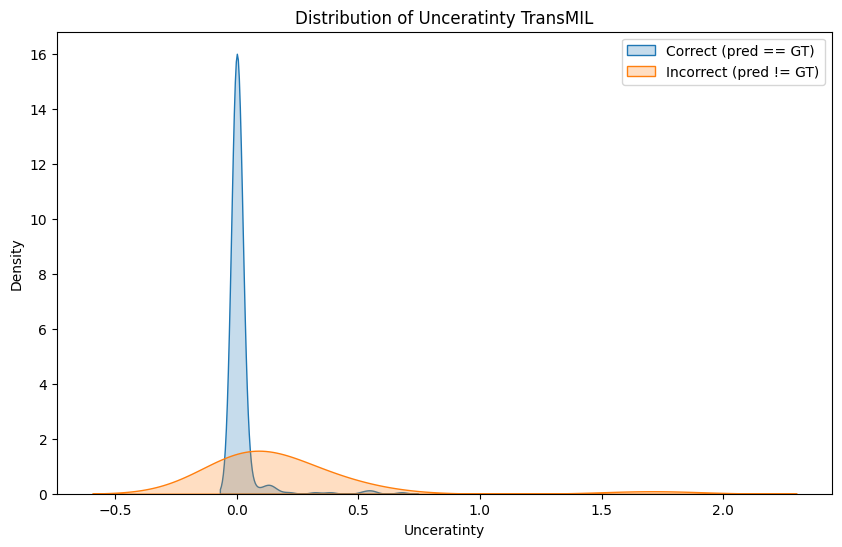

In [361]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings(action = 'ignore')
df = pd.read_csv(f"/mnt/e/results/data1/x5_x10/256/DTFD-MIL-AFS/vit-ssl-dino-p16/nontext/seed_1/wrong_predictions.csv")

# pred와 label이 일치하는 경우와 일치하지 않는 경우 구분
df["correct"] = df["GT"] == df["Pred"]

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df["correct"] == True], x="Unceratinty", label="Correct (pred == GT)", shade=True)
sns.kdeplot(data=df[df["correct"] == False], x="Unceratinty", label="Incorrect (pred != GT)", shade=True)

# 그래프 설정
plt.title(f"Distribution of Unceratinty {model}")
plt.xlabel("Unceratinty")
plt.ylabel("Density")
plt.legend()
plt.show()

In [173]:
import pandas as pd 
HP = pd.read_excel(f"/mnt/e/Colon_included_240719.xlsx", sheet_name = 'HP')

print(len(HP))

def age_group(age):
    if age < 10:
        return '0대'
    elif 10 <= age < 20:
        return '10대'
    elif 20 <= age < 30:
        return '20대'
    elif 30 <= age < 40:
        return '30대'
    elif 40 <= age < 50:
        return '40대'
    elif 50 <= age < 60:
        return '50대'
    elif 60 <= age < 70:
        return '60대'
    else:
        return '70대 이상'

HP['Age Group'] = HP['Age'].apply(age_group)


import pandas as pd
from sklearn.model_selection import train_test_split

HP['stratify_col'] = HP['Gender'].astype(str) + '_' + HP['Age Group'].astype(str)

counts = HP['stratify_col'].value_counts()
human  = HP[HP['stratify_col'].isin(counts[counts < 2].index)]
HP = HP[HP['stratify_col'].isin(counts[counts >= 2].index)]

# Train + Temp 나누기 (7:3 비율)
train_hp, temp_hp = train_test_split(
    HP,
    test_size=0.3,
    stratify = HP['stratify_col'],
    random_state=42
)

counts = temp_hp['stratify_col'].value_counts()
human_  = temp_hp[temp_hp['stratify_col'].isin(counts[counts < 2].index)]
temp_hp = temp_hp[temp_hp['stratify_col'].isin(counts[counts >= 2].index)]

# Temp를 다시 Validation + Test로 나누기 (1.5:1.5 비율)
val_hp, test_hp = train_test_split(
    temp_hp,
    test_size = 0.5,
    stratify = temp_hp['stratify_col'],
    random_state=42
)


train_hp = pd.concat([train_hp,human,human_],axis = 0).reset_index(drop =True)

print(len(train_hp))
print(len(val_hp))
print(len(test_hp))


train_hp = train_hp.drop(['stratify_col', 'Age Group'], axis= 1)
train_hp['type'] = 'train'
val_hp = val_hp.drop(['stratify_col', 'Age Group'], axis= 1)
val_hp['type'] = 'val'
test_hp = test_hp.drop(['stratify_col', 'Age Group'], axis= 1)
test_hp['type'] = 'test'

train_hp['Class'] = 'HP'
val_hp['Class'] = 'HP'
test_hp['Class'] = 'HP'



489
345
72
72


In [174]:
import pandas as pd 
TA = pd.read_excel(f"/mnt/e/Colon_included_240719.xlsx", sheet_name = 'TA')

print(len(TA))

def age_group(age):
    if age < 10:
        return '0대'
    elif 10 <= age < 20:
        return '10대'
    elif 20 <= age < 30:
        return '20대'
    elif 30 <= age < 40:
        return '30대'
    elif 40 <= age < 50:
        return '40대'
    elif 50 <= age < 60:
        return '50대'
    elif 60 <= age < 70:
        return '60대'
    else:
        return '70대 이상'

TA['Age Group'] = TA['Age'].apply(age_group)


import pandas as pd
from sklearn.model_selection import train_test_split

TA['stratify_col'] = TA['Gender'].astype(str) + '_' + TA['Age Group'].astype(str)

counts = TA['stratify_col'].value_counts()
human_ta  = TA[TA['stratify_col'].isin(counts[counts < 2].index)]
TA = TA[TA['stratify_col'].isin(counts[counts >= 2].index)]

# Train + Temp 나누기 (7:3 비율)
train_ta, temp_ta = train_test_split(
    TA,
    test_size=0.3,
    stratify = TA['stratify_col'],
    random_state=42
)

counts = temp_ta['stratify_col'].value_counts()
human_ta2  = temp_ta[temp_ta['stratify_col'].isin(counts[counts < 2].index)]
temp_ta = temp_ta[temp_ta['stratify_col'].isin(counts[counts >= 2].index)]

# Temp를 다시 Validation + Test로 나누기 (1.5:1.5 비율)
val_ta, test_ta = train_test_split(
    temp_ta,
    test_size = 0.5,
    stratify = temp_ta['stratify_col'],
    random_state=42
)


train_ta = pd.concat([train_ta,human_ta,human_ta2],axis = 0).reset_index(drop =True)

print(len(train_ta))
print(len(val_ta))
print(len(test_ta))


train_ta = train_ta.drop(['stratify_col', 'Age Group'], axis= 1)
train_ta['type'] = 'train'
val_ta = val_ta.drop(['stratify_col', 'Age Group'], axis= 1)
val_ta['type'] = 'val'
test_ta = test_ta.drop(['stratify_col', 'Age Group'], axis= 1)
test_ta['type'] = 'test'

train_ta['Class'] = 'TA'
val_ta['Class'] = 'TA'
test_ta['Class'] = 'TA'


905
633
136
136


In [175]:
import pandas as pd 
TSA = pd.read_excel(f"/mnt/e/Colon_included_240719.xlsx", sheet_name = 'TSA')

print(len(TSA))

def age_group(age):
    if age < 10:
        return '0대'
    elif 10 <= age < 20:
        return '10대'
    elif 20 <= age < 30:
        return '20대'
    elif 30 <= age < 40:
        return '30대'
    elif 40 <= age < 50:
        return '40대'
    elif 50 <= age < 60:
        return '50대'
    elif 60 <= age < 70:
        return '60대'
    else:
        return '70대 이상'

TSA['Age Group'] = TSA['Age'].apply(age_group)


import pandas as pd
from sklearn.model_selection import train_test_split

TSA['stratify_col'] = TSA['Gender'].astype(str) + '_' + TSA['Age Group'].astype(str)

counts = TSA['stratify_col'].value_counts()
human_tsa  = TSA[TSA['stratify_col'].isin(counts[counts < 2].index)]
TSA = TSA[TSA['stratify_col'].isin(counts[counts >= 2].index)]

# Train + Temp 나누기 (7:3 비율)
train_tsa, temp_tsa = train_test_split(
    TSA,
    test_size=0.3,
    stratify = TSA['stratify_col'],
    random_state=42
)

counts = temp_tsa['stratify_col'].value_counts()
human_tsa2  = temp_tsa[temp_tsa['stratify_col'].isin(counts[counts < 2].index)]
temp_tsa = temp_tsa[temp_tsa['stratify_col'].isin(counts[counts >= 2].index)]

# Temp를 다시 Validation + Test로 나누기 (1.5:1.5 비율)
val_tsa, test_tsa = train_test_split(
    temp_tsa,
    test_size = 0.5,
    stratify = temp_tsa['stratify_col'],
    random_state=42
)


train_tsa = pd.concat([train_tsa,human_tsa,human_tsa2],axis = 0).reset_index(drop =True)

print(len(train_tsa))
print(len(val_tsa))
print(len(test_tsa))

train_tsa = train_tsa.drop(['stratify_col', 'Age Group'], axis= 1)
train_tsa['type'] = 'train'
val_tsa = val_tsa.drop(['stratify_col', 'Age Group'], axis= 1)
val_tsa['type'] = 'val'
test_tsa = test_tsa.drop(['stratify_col', 'Age Group'], axis= 1)
test_tsa['type'] = 'test'

train_tsa['Class'] = 'TSA'
val_tsa['Class'] = 'TSA'
test_tsa['Class'] = 'TSA'



122
87
17
18


In [176]:
import pandas as pd 
LP = pd.read_excel(f"/mnt/e/Colon_included_240719.xlsx", sheet_name = 'LP')

print(len(LP))

def age_group(age):
    if age < 10:
        return '0대'
    elif 10 <= age < 20:
        return '10대'
    elif 20 <= age < 30:
        return '20대'
    elif 30 <= age < 40:
        return '30대'
    elif 40 <= age < 50:
        return '40대'
    elif 50 <= age < 60:
        return '50대'
    elif 60 <= age < 70:
        return '60대'
    else:
        return '70대 이상'

LP['Age Group'] = LP['Age'].apply(age_group)


import pandas as pd
from sklearn.model_selection import train_test_split

LP['stratify_col'] = LP['Gender'].astype(str) + '_' + LP['Age Group'].astype(str)

counts = LP['stratify_col'].value_counts()
human_lp  = LP[LP['stratify_col'].isin(counts[counts < 2].index)]
LP = LP[LP['stratify_col'].isin(counts[counts >= 2].index)]

# Train + Temp 나누기 (7:3 비율)
train_lp, temp_lp = train_test_split(
    LP,
    test_size=0.3,
    stratify = LP['stratify_col'],
    random_state=42
)

counts = temp_lp['stratify_col'].value_counts()
human_lp2  = temp_lp[temp_lp['stratify_col'].isin(counts[counts < 2].index)]
temp_lp = temp_lp[temp_lp['stratify_col'].isin(counts[counts >= 2].index)]

# Temp를 다시 Validation + Test로 나누기 (1.5:1.5 비율)
val_lp, test_lp = train_test_split(
    temp_lp,
    test_size = 0.5,
    stratify = temp_lp['stratify_col'],
    random_state=42
)


train_lp = pd.concat([train_lp,human_lp,human_lp2],axis = 0).reset_index(drop =True)

print(len(train_lp))
print(len(val_lp))
print(len(test_lp))

train_lp = train_lp.drop(['stratify_col', 'Age Group'], axis= 1)
train_lp['type'] = 'train'
val_lp = val_lp.drop(['stratify_col', 'Age Group'], axis= 1)
val_lp['type'] = 'val'
test_lp = test_lp.drop(['stratify_col', 'Age Group'], axis= 1)
test_lp['type'] = 'test'

train_lp['Class'] = 'LP'
val_lp['Class'] = 'LP'
test_lp['Class'] = 'LP'



254
179
37
38


In [177]:
import pandas as pd 
IP = pd.read_excel(f"/mnt/e/Colon_included_240719.xlsx", sheet_name = 'IP')

print(len(IP))

def age_group(age):
    if age < 10:
        return '0대'
    elif 10 <= age < 20:
        return '10대'
    elif 20 <= age < 30:
        return '20대'
    elif 30 <= age < 40:
        return '30대'
    elif 40 <= age < 50:
        return '40대'
    elif 50 <= age < 60:
        return '50대'
    elif 60 <= age < 70:
        return '60대'
    else:
        return '70대 이상'

IP['Age Group'] = IP['Age'].apply(age_group)


import pandas as pd
from sklearn.model_selection import train_test_split

IP['stratify_col'] = IP['Gender'].astype(str) + '_' + IP['Age Group'].astype(str)

counts = IP['stratify_col'].value_counts()
human_ip  = IP[IP['stratify_col'].isin(counts[counts < 2].index)]
IP = IP[IP['stratify_col'].isin(counts[counts >= 2].index)]

# Train + Temp 나누기 (7:3 비율)
train_ip, temp_ip = train_test_split(
    IP,
    test_size=0.3,
    stratify = IP['stratify_col'],
    random_state=42
)

counts = temp_ip['stratify_col'].value_counts()
human_ip2  = temp_ip[temp_ip['stratify_col'].isin(counts[counts < 2].index)]
temp_ip = temp_ip[temp_ip['stratify_col'].isin(counts[counts >= 2].index)]

# Temp를 다시 Validation + Test로 나누기 (1.5:1.5 비율)
val_ip, test_ip = train_test_split(
    temp_ip,
    test_size = 0.5,
    stratify = temp_ip['stratify_col'],
    random_state=42
)


train_ip = pd.concat([train_ip,human_ip,human_ip2],axis = 0).reset_index(drop =True)

print(len(train_ip))
print(len(val_ip))
print(len(test_ip))

train_ip = train_ip.drop(['stratify_col', 'Age Group'], axis= 1)
train_ip['type'] = 'train'
val_ip = val_ip.drop(['stratify_col', 'Age Group'], axis= 1)
val_ip['type'] = 'val'
test_ip = test_ip.drop(['stratify_col', 'Age Group'], axis= 1)
test_ip['type'] = 'test'

train_ip['Class'] = 'IP'
val_ip['Class'] = 'IP'
test_ip['Class'] = 'IP'


115
82
16
17


In [178]:
import pandas as pd 
SSL = pd.read_excel(f"/mnt/e/Colon_included_240719.xlsx", sheet_name = 'SSL')

print(len(SSL))

def age_group(age):
    if age < 10:
        return '0대'
    elif 10 <= age < 20:
        return '10대'
    elif 20 <= age < 30:
        return '20대'
    elif 30 <= age < 40:
        return '30대'
    elif 40 <= age < 50:
        return '40대'
    elif 50 <= age < 60:
        return '50대'
    elif 60 <= age < 70:
        return '60대'
    else:
        return '70대 이상'

SSL['Age Group'] = SSL['Age'].apply(age_group)


import pandas as pd
from sklearn.model_selection import train_test_split

SSL['stratify_col'] = SSL['Gender'].astype(str) + '_' + SSL['Age Group'].astype(str)

counts = SSL['stratify_col'].value_counts()
human_SSL  = SSL[SSL['stratify_col'].isin(counts[counts < 2].index)]
SSL = SSL[SSL['stratify_col'].isin(counts[counts >= 2].index)]

# Train + Temp 나누기 (7:3 비율)
train_SSL, temp_SSL = train_test_split(
    SSL,
    test_size=0.3,
    stratify = SSL['stratify_col'],
    random_state=42
)

counts = temp_SSL['stratify_col'].value_counts()
human_SSL2  = temp_SSL[temp_SSL['stratify_col'].isin(counts[counts < 2].index)]
temp_SSL = temp_SSL[temp_SSL['stratify_col'].isin(counts[counts >= 2].index)]

# Temp를 다시 Validation + Test로 나누기 (1.5:1.5 비율)
val_SSL, test_SSL = train_test_split(
    temp_SSL,
    test_size = 0.5,
    stratify = temp_SSL['stratify_col'],
    random_state=42
)


train_SSL = pd.concat([train_SSL,human_SSL,human_SSL2],axis = 0).reset_index(drop =True)

print(len(train_SSL))
print(len(val_SSL))
print(len(test_SSL))

train_SSL = train_SSL.drop(['stratify_col', 'Age Group'], axis= 1)
train_SSL['type'] = 'train'
val_SSL = val_SSL.drop(['stratify_col', 'Age Group'], axis= 1)
val_SSL['type'] = 'val'
test_SSL = test_SSL.drop(['stratify_col', 'Age Group'], axis= 1)
test_SSL['type'] = 'test'

train_SSL['Class'] = 'SSL'
val_SSL['Class'] = 'SSL'
test_SSL['Class'] = 'SSL'


212
152
30
30


In [179]:
import pandas as pd 
TVA = pd.read_excel(f"/mnt/e/Colon_included_240719.xlsx", sheet_name = 'TVA')

print(len(TVA))

def age_group(age):
    if age < 10:
        return '0대'
    elif 10 <= age < 20:
        return '10대'
    elif 20 <= age < 30:
        return '20대'
    elif 30 <= age < 40:
        return '30대'
    elif 40 <= age < 50:
        return '40대'
    elif 50 <= age < 60:
        return '50대'
    elif 60 <= age < 70:
        return '60대'
    else:
        return '70대 이상'

TVA['Age Group'] = TVA['Age'].apply(age_group)


import pandas as pd
from sklearn.model_selection import train_test_split

TVA['stratify_col'] = TVA['Gender'].astype(str) + '_' + TVA['Age Group'].astype(str)

counts = TVA['stratify_col'].value_counts()
human_TVA  = TVA[TVA['stratify_col'].isin(counts[counts < 2].index)]
TVA = TVA[TVA['stratify_col'].isin(counts[counts >= 2].index)]

# Train + Temp 나누기 (7:3 비율)
train_TVA, temp_TVA = train_test_split(
    TVA,
    test_size=0.3,
    stratify = TVA['stratify_col'],
    random_state=42
)

counts = temp_TVA['stratify_col'].value_counts()
human_TVA2  = temp_TVA[temp_TVA['stratify_col'].isin(counts[counts < 2].index)]
temp_TVA = temp_TVA[temp_TVA['stratify_col'].isin(counts[counts >= 2].index)]

# Temp를 다시 Validation + Test로 나누기 (1.5:1.5 비율)
val_TVA, test_TVA = train_test_split(
    temp_TVA,
    test_size = 0.5,
    stratify = temp_TVA['stratify_col'],
    random_state=42
)


train_TVA = pd.concat([train_TVA,human_TVA,human_TVA2],axis = 0).reset_index(drop =True)

print(len(train_TVA))
print(len(val_TVA))
print(len(test_TVA))

train_TVA = train_TVA.drop(['stratify_col', 'Age Group'], axis= 1)
train_TVA['type'] = 'train'
val_TVA = val_TVA.drop(['stratify_col', 'Age Group'], axis= 1)
val_TVA['type'] = 'val'
test_TVA = test_TVA.drop(['stratify_col', 'Age Group'], axis= 1)
test_TVA['type'] = 'test'

train_TVA['Class'] = 'TVA'
val_TVA['Class'] = 'TVA'
test_TVA['Class'] = 'TVA'

158
111
23
24


In [180]:
train = pd.concat([train_hp,train_ip,train_lp,train_ta,train_tsa,train_SSL,train_TVA]).reset_index(drop = True)
val = pd.concat([val_hp,val_ip,val_lp,val_ta,val_tsa,val_SSL,val_TVA]).reset_index(drop = True)
test = pd.concat([test_hp,test_ip,test_lp,test_ta,test_tsa,test_SSL,test_TVA]).reset_index(drop = True)

In [181]:
final = pd.concat([train,val,test], axis = 0).reset_index(drop = True)
final

,Slide_ID,Date_receipt,Gender,Age,Heading,Subsite,type,Class
0,2022S 0073077070101,20220307,F,64,"Colon, sigmoid, colonoscopic polypectomy:",1,train,HP
1,2022S 0074828020101,20220308,M,68,"Colon, 20cm from anal verge, colonoscopic poly...",1,train,HP
2,2022S 0074775090101,20220308,M,68,"Colon, sigmoid, colonoscopic polypectomy:",1,train,HP
3,2022S 0073502010101,20220307,F,76,"Colon, transverse, colonoscopic mucosal resect...",0,train,HP
4,2022S 0073636030101,20220307,M,65,"Rectum, colonoscopic polypectomy:",1,train,HP
...,...,...,...,...,...,...,...,...
2250,2023S 0012692010101,20230111,F,53,"Rectum, colonoscopic polypectomy:",1,test,TVA
2251,2022S 0208392080101,20220616,M,57,"Colon, transverse, colonoscopic polypectomy:",0,test,TVA
2252,2022S 0208079010101,20220616,F,81,"Colon, transverse, colonoscopic mucosal resect...",0,test,TVA
2253,2022S 0435149010101,20221105,M,59,"Colon, 25cm above anal verge, colonoscopic muc...",1,test,TVA


In [182]:
final['Class'].isnull().sum()

0

In [184]:
final.to_excel("/mnt/e/data_split_1118.xlsx")

In [193]:
test['Class'].value_counts()

Class
TA     136
HP      72
LP      38
SSL     30
TVA     24
TSA     18
IP      17
Name: count, dtype: int64

In [202]:

def age_group(age):
    if age < 10:
        return '0대'
    elif 10 <= age < 20:
        return '10대'
    elif 20 <= age < 30:
        return '20대'
    elif 30 <= age < 40:
        return '30대'
    elif 40 <= age < 50:
        return '40대'
    elif 50 <= age < 60:
        return '50대'
    elif 60 <= age < 70:
        return '60대'
    else:
        return '70대 이상'

train['Age Group'] = train['Age'].apply(age_group)
val['Age Group'] = val['Age'].apply(age_group)
test['Age Group'] = test['Age'].apply(age_group)

In [204]:
from scipy.stats import chi2_contingency

train_class_counts = train['Age Group'].value_counts()
test_class_counts = test['Age Group'].value_counts()

# 두 집단의 클래스 분포 합치기 (contingency table)
contingency_table = pd.DataFrame({
    'Train': train_class_counts,
    'Test': test_class_counts
}).fillna(0).T  # 결측값은 0으로 채우기

print("Contingency Table:")
print(contingency_table)

# 카이제곱 검정 실행
chi2, p, dof, expected = chi2_contingency(contingency_table)

# 결과 출력
print(f"\nChi-Square Statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies:\n{pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)}")


Contingency Table:
Age Group    0대  10대   20대   30대    40대    50대    60대  70대 이상
Train      15.0  1.0  25.0  98.0  249.0  418.0  522.0   261.0
Test        1.0  0.0   1.0  16.0   56.0   91.0  116.0    54.0

Chi-Square Statistic: 6.375163641087647
p-value: 0.4966884904359371
Degrees of Freedom: 7
Expected Frequencies:
Age Group         0대       10대        20대        30대         40대        50대  \
Train      13.214137  0.825884  21.472973  94.150728  251.894491  420.37474   
Test        2.785863  0.174116   4.527027  19.849272   53.105509   88.62526   

Age Group         60대      70대 이상  
Train      526.913721  260.153326  
Test       111.086279   54.846674  


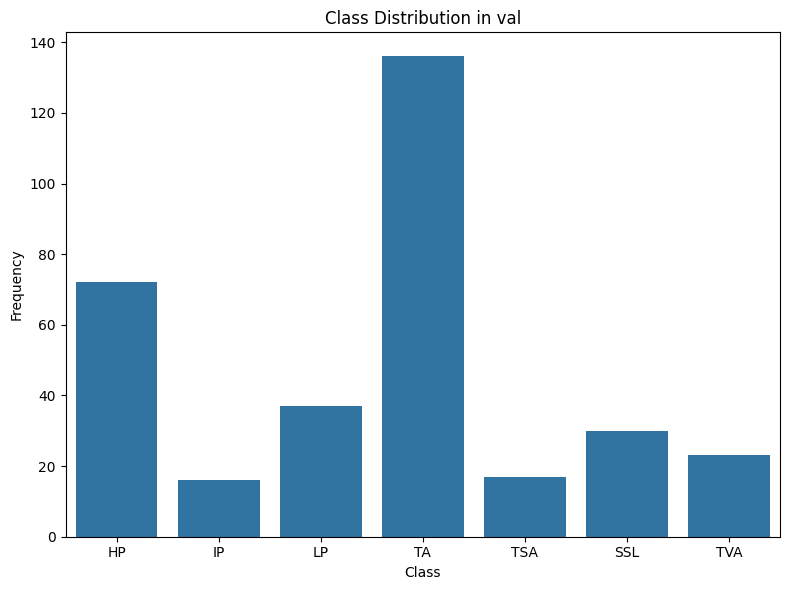

In [215]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 예제 데이터: Train과 Test 데이터

# Seaborn 그래프
plt.figure(figsize=(8, 6))
sns.countplot(data=val, x='Class')
plt.title("Class Distribution in val")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1684046/922200628.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=test, x="Class", y="Age", jitter=True, palette="Set2")


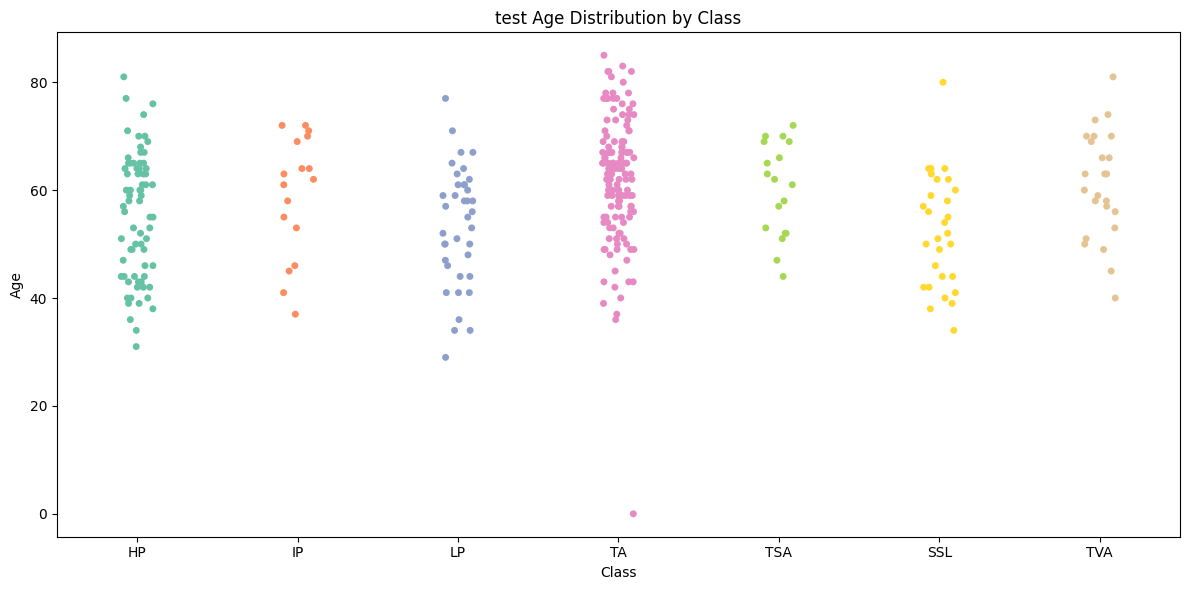

In [219]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 예제 데이터: Train과 Test 데이터

plt.figure(figsize=(12, 6))
sns.stripplot(data=test, x="Class", y="Age", jitter=True, palette="Set2")
plt.title("test Age Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

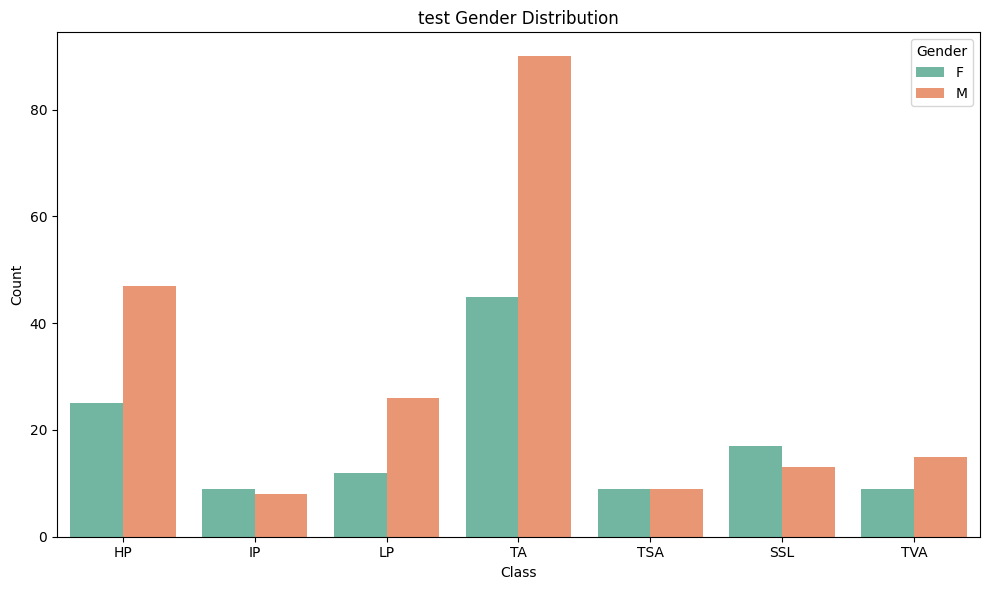

In [223]:
plt.figure(figsize=(10, 6))
sns.countplot(data=test, x="Class", hue="Gender", palette="Set2")
plt.title("test Gender Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [36]:
torch.ones_like([3])

TypeError: ones_like(): argument 'input' (position 1) must be Tensor, not list

In [23]:
inputs_2 = torch.cat([input, t_inputs], dim=1).to('cuda')

In [24]:
extra_channel = -20 * torch.ones_like(input[:, :1, :, :])
inputs_1 = torch.cat([input, extra_channel], dim=1).to('cuda')
t_inputs = labels.reshape(-1, 1, 1, 1) * torch.ones_like(input[:, :1, :, :])
inputs_2 = torch.cat([input, t_inputs], dim=1).to('cuda')

In [31]:
input[0]

tensor([[[0.4459, 0.0515, 0.3250,  ..., 0.9052, 0.4254, 0.5491],
         [0.6025, 0.9195, 0.5324,  ..., 0.2701, 0.0063, 0.7721],
         [0.1880, 0.4909, 0.2741,  ..., 0.5089, 0.1193, 0.2726],
         ...,
         [0.7602, 0.2215, 0.2007,  ..., 0.5876, 0.2825, 0.2985],
         [0.5645, 0.7226, 0.1344,  ..., 0.4628, 0.0936, 0.8354],
         [0.2545, 0.6724, 0.6209,  ..., 0.1973, 0.6069, 0.6259]],

        [[0.4997, 0.6144, 0.8390,  ..., 0.0981, 0.9910, 0.9159],
         [0.1552, 0.8571, 0.1359,  ..., 0.9383, 0.9373, 0.5839],
         [0.7165, 0.9008, 0.7500,  ..., 0.0734, 0.7633, 0.8350],
         ...,
         [0.3479, 0.5956, 0.4770,  ..., 0.6236, 0.1502, 0.5984],
         [0.4942, 0.4703, 0.2999,  ..., 0.1681, 0.3964, 0.0624],
         [0.9049, 0.1266, 0.9901,  ..., 0.8563, 0.3115, 0.4946]],

        [[0.6172, 0.2070, 0.1206,  ..., 0.8956, 0.1627, 0.6770],
         [0.2913, 0.5662, 0.8689,  ..., 0.4468, 0.3965, 0.8034],
         [0.1253, 0.5124, 0.6770,  ..., 0.0505, 0.8897, 0.

In [32]:
inputs_2[0]

tensor([[[0.4459, 0.0515, 0.3250,  ..., 0.9052, 0.4254, 0.5491],
         [0.6025, 0.9195, 0.5324,  ..., 0.2701, 0.0063, 0.7721],
         [0.1880, 0.4909, 0.2741,  ..., 0.5089, 0.1193, 0.2726],
         ...,
         [0.7602, 0.2215, 0.2007,  ..., 0.5876, 0.2825, 0.2985],
         [0.5645, 0.7226, 0.1344,  ..., 0.4628, 0.0936, 0.8354],
         [0.2545, 0.6724, 0.6209,  ..., 0.1973, 0.6069, 0.6259]],

        [[0.4997, 0.6144, 0.8390,  ..., 0.0981, 0.9910, 0.9159],
         [0.1552, 0.8571, 0.1359,  ..., 0.9383, 0.9373, 0.5839],
         [0.7165, 0.9008, 0.7500,  ..., 0.0734, 0.7633, 0.8350],
         ...,
         [0.3479, 0.5956, 0.4770,  ..., 0.6236, 0.1502, 0.5984],
         [0.4942, 0.4703, 0.2999,  ..., 0.1681, 0.3964, 0.0624],
         [0.9049, 0.1266, 0.9901,  ..., 0.8563, 0.3115, 0.4946]],

        [[0.6172, 0.2070, 0.1206,  ..., 0.8956, 0.1627, 0.6770],
         [0.2913, 0.5662, 0.8689,  ..., 0.4468, 0.3965, 0.8034],
         [0.1253, 0.5124, 0.6770,  ..., 0.0505, 0.8897, 0.

In [6]:
inputs_1[0][3].shape

torch.Size([32, 32])

In [41]:
resnet18()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [42]:
model = resnet18()
model.conv1 = nn.Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model.fc = nn.Linear(512,10)

model(input)

tensor([[-8.3860e-01,  4.3114e-01,  8.7118e-01,  1.9099e+00, -5.9921e-01,
          9.7952e-01, -1.2278e+00, -3.6905e-01,  6.0853e-02,  1.2879e-01],
        [-1.0172e+00,  3.2738e-01,  1.1696e-01,  1.3302e+00, -1.1844e+00,
         -8.5538e-02, -1.1962e+00,  9.1632e-01,  5.8737e-01, -7.1383e-01],
        [-6.9480e-01,  1.1469e+00, -3.8867e-01,  6.3764e-01, -1.5025e+00,
          3.1066e-01,  1.9193e-05, -3.7531e-02, -4.1056e-01, -2.5756e-01]],
       grad_fn=<AddmmBackward0>)

In [4]:
import torch
import torch.nn.functional as F

# 예시: 배치 크기 4, 클래스 수 3
prob1 = torch.tensor([[0.2, 0.3, 0.5], [0.1, 0.7, 0.2], [0.4, 0.4, 0.2], [0.3, 0.4, 0.3]], requires_grad=True)
prob2 = torch.tensor([[0.1, 0.2, 0.7], [0.3, 0.4, 0.3], [0.3, 0.5, 0.2], [0.4, 0.3, 0.3]])

# KL divergence 계산 (각 샘플의 클래스별로 KL divergence를 구함)
kl_div = F.kl_div(prob1.log(), prob2, reduction='none')

# 클래스 차원(dim=1)으로 합산하여 각 샘플에 대한 KL divergence를 계산
sample_kl_div = kl_div.sum(dim=1)

print(kl_div)

tensor([[-0.0693, -0.0811,  0.2355],
        [ 0.3296, -0.2238,  0.1216],
        [-0.0863,  0.1116,  0.0000],
        [ 0.1151, -0.0863,  0.0000]], grad_fn=<SubBackward0>)


In [3]:
logvar = torch.rand([3,32])        
std = torch.exp(0.5 * logvar)
eps = torch.randn_like(std)

In [7]:
a = std * eps
a.shape

torch.Size([3, 32])

In [5]:
import os
import json
import random
import numpy as np
import yaml

import torch
import torch.nn as nn
import pytorch_lightning as pl

from torchmetrics import MetricCollection, Accuracy, AUROC, Precision, Recall
from torchmetrics import F1Score as F1



seed=4
pl.seed_everything(seed) # ADDED
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

epsilon = torch.randn((30, 30), device= 'cuda')
epsilon

Global seed set to 4


tensor([[-1.9505e+00, -6.0545e-02, -3.3960e-01, -3.1978e-01,  1.3436e+00,
          9.9312e-01, -1.3681e+00, -1.8513e-01,  1.1702e+00, -6.6699e-01,
          3.8559e-01, -6.8042e-01, -2.8730e-01,  1.3557e+00, -3.3765e-01,
          7.6571e-02, -9.6994e-01, -2.5146e-01,  5.0646e-01,  1.8284e+00,
          5.6068e-01, -4.4801e-01,  9.7643e-01, -9.0860e-01,  8.4949e-01,
          6.4753e-02, -7.6435e-01,  8.4226e-01,  1.6087e+00,  6.9735e-01],
        [-8.9923e-01, -1.9795e+00,  1.0861e+00,  8.5285e-01,  2.7103e-01,
         -1.1971e+00, -5.5699e-01, -1.2689e+00, -1.2356e+00, -1.4996e+00,
          3.5225e-01, -8.0694e-01, -1.8657e+00,  1.8740e+00,  4.6679e-01,
         -1.7115e-01,  3.4962e-01,  4.5111e-01,  1.6365e+00,  5.8835e-02,
          1.5390e+00,  5.9406e-01,  1.7437e+00,  1.4267e+00,  8.6933e-02,
          3.1131e-03, -1.6427e+00, -2.5608e+00, -1.1516e+00, -4.0410e-01],
        [-7.3860e-01, -8.5718e-02,  2.2742e+00,  1.0451e+00, -2.1869e+00,
         -6.2434e-01, -8.1335e-01,  

In [4]:
resnet = resnet18(pretrained=True)
feature_extractor = list(resnet.children())[-1]

In [5]:
feature_extractor

Linear(in_features=512, out_features=1000, bias=True)

In [9]:
h = feature_extractor(input)
h = torch.flatten(h, 1) 

In [12]:
h.shape

torch.Size([3, 512])

In [26]:
class CusmtomResnet(nn.Module):
    def __init__(self,class_num,dim = 512 ):
        super(CusmtomResnet,self).__init__()
        
        self.feature_extractor = resnet18(pretrained=True)
        num_ftrs = self.feature_extractor.fc.in_features
        self.feature_extractor.fc = nn.Linear(num_ftrs, 128)

        self.fc =  nn.Linear(128, class_num) 

    def forward(self, x):
        features = self.feature_extractor(x)
        emb = features.view(features.size(0), -1)  # Flatten the features
        output = self.fc(emb)
        return output, emb



In [27]:
model = CusmtomResnet(10)

/home/nh/anaconda3/envs/benchmark_mil/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nh/anaconda3/envs/benchmark_mil/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [28]:
output,emb = model(input)

In [30]:
output.shape

torch.Size([3, 10])

In [13]:
mask = (torch.empty(input.shape[0], 1, 1, 1).uniform_(0, 1) > .5)
mask.shape

torch.Size([3, 1, 1, 1])

In [29]:
(0.3901 + 0.1152 + 0.2737 + 0.0731 + 0.3163)/5

0.23367999999999997

In [1]:
output = torch.stack([F.softmax(output, dim=1) for output in outputs])
output

NameError: name 'torch' is not defined

In [33]:
mean_probs = torch.mean(output, dim=0)  # [batch_size, num_classes], 소프트맥스 평균
mean_preds = mean_probs.argmax(dim=1)
mean_preds

tensor([1, 0, 1])

In [34]:
preds = [out.argmax(dim=1) for out in output]  # 각 모델의 예측 라벨 추출
preds = torch.stack(preds)  # [num_samples, batch_size]
uncertainty = preds.float().var(dim=0)  # [batch_size] 예측 라벨 간 분산을 사용해 불확실성 측정

In [1]:
from torchvision.models import resnet18
model = resnet18(pretrained=True)

/home/nh/anaconda3/envs/benchmark_mil/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nh/anaconda3/envs/benchmark_mil/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [38]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
import torch.nn as nn
import torch.nn.functional as F

class CusmtomResnet(nn.Module):
    def __init__(self,class_num):
        super(CusmtomResnet,self).__init__()

        self.feature_extractor = resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(self.feature_extractor.children())[:-1])

        self.reduction = nn.Sequential(nn.Linear(512 +  class_num  , 256),
                                       nn.ReLU(),
                                       nn.Linear(256  , 128),
                                       nn.ReLU())
        
        self.fc =  nn.Linear(128, class_num) 
        
        
        self.criterion = nn.CrossEntropyLoss()
        self.class_num = class_num        

    def forward(self, x, vector):
        features = self.feature_extractor(x)
        features = features.view(features.size(0), -1)  # Flatten the features


        features = torch.cat([features,vector], dim=1)
        features = self.reduction(features)
        output = self.fc(features)

        return output,features

In [31]:
import torch 
x= torch.rand([6,3,32,32])
model = CusmtomResnet(10)

/home/nh/anaconda3/envs/benchmark_mil/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nh/anaconda3/envs/benchmark_mil/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [32]:
vec = torch.zeros([6, 10])
output1,emb1 = model(x, vec)
output1_soft  = F.softmax(output1, dim=1)
output2,emb2 = model(x,output1_soft)


In [33]:
predicted1 = torch.argmax(F.log_softmax(output1, dim=1), dim=1)

In [34]:
correct_features1 = []
correct_features2 = []
correct_features1.append(emb1)
correct_features2.append(emb2)
correct_features1 = torch.cat(correct_features1, dim=0)
correct_features2 = torch.cat(correct_features2, dim=0)

In [35]:
class_means1 = []
total_covariance1 = torch.zeros((correct_features1.size(1), correct_features1.size(1)))

class_means2 = []
total_covariance2 = torch.zeros((correct_features2.size(1), correct_features2.size(1)))

In [36]:
for _ in range(10): 
    class_mean1 = correct_features1.mean(dim=0)
    class_means1.append(class_mean1)
    covariance1 = (correct_features1 - class_mean1).t() @ (correct_features1 - class_mean1) / correct_features1.size(0)
    total_covariance1 += covariance1
    class_mean2 = correct_features2.mean(dim=0)
    class_means2.append(class_mean2)
    covariance2 = (correct_features2 - class_mean2).t() @ (correct_features2 - class_mean2) / correct_features2.size(0)
    total_covariance2 += covariance2


In [37]:
total_covariance1 /= 10
class_means1 = torch.stack(class_means1, dim=0)
total_covariance2 /= 10
class_means2 = torch.stack(class_means2, dim=0)

In [41]:
print(class_means1)
print(total_covariance1)
print(class_means2)
print(total_covariance2)

tensor([[0.0063, 0.0000, 0.0515,  ..., 0.1173, 0.2245, 0.5391],
        [0.0063, 0.0000, 0.0515,  ..., 0.1173, 0.2245, 0.5391],
        [0.0063, 0.0000, 0.0515,  ..., 0.1173, 0.2245, 0.5391],
        ...,
        [0.0063, 0.0000, 0.0515,  ..., 0.1173, 0.2245, 0.5391],
        [0.0063, 0.0000, 0.0515,  ..., 0.1173, 0.2245, 0.5391],
        [0.0063, 0.0000, 0.0515,  ..., 0.1173, 0.2245, 0.5391]],
       grad_fn=<StackBackward0>)
tensor([[ 0.0002,  0.0000,  0.0004,  ...,  0.0018, -0.0002, -0.0014],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0004,  0.0000,  0.0059,  ...,  0.0113, -0.0016,  0.0125],
        ...,
        [ 0.0018,  0.0000,  0.0113,  ...,  0.0286, -0.0038,  0.0097],
        [-0.0002,  0.0000, -0.0016,  ..., -0.0038,  0.0390,  0.0033],
        [-0.0014,  0.0000,  0.0125,  ...,  0.0097,  0.0033,  0.0709]],
       grad_fn=<DivBackward0>)
tensor([[0.0060, 0.0000, 0.0524,  ..., 0.1175, 0.2247, 0.5332],
        [0.0060, 0.0000, 0.0524,  ..., 0

In [42]:
x= torch.rand([6,3,32,32])
vec = torch.zeros([6, 10])
output1,emb1 = model(x, vec)
output1_soft  = F.softmax(output1, dim=1)
output2,emb2 = model(x,output1_soft)

In [45]:
total_covariance1

tensor([[ 0.0002,  0.0000,  0.0004,  ...,  0.0018, -0.0002, -0.0014],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0004,  0.0000,  0.0059,  ...,  0.0113, -0.0016,  0.0125],
        ...,
        [ 0.0018,  0.0000,  0.0113,  ...,  0.0286, -0.0038,  0.0097],
        [-0.0002,  0.0000, -0.0016,  ..., -0.0038,  0.0390,  0.0033],
        [-0.0014,  0.0000,  0.0125,  ...,  0.0097,  0.0033,  0.0709]],
       grad_fn=<DivBackward0>)

In [47]:
epsilon = 1e-5
reg_covariance = total_covariance1 + epsilon * torch.eye(total_covariance1.size(0))
inv_covariance = torch.inverse(reg_covariance)

In [48]:
class_means_yi = class_means1[3] 

In [52]:
diff = emb1 - class_means_yi
diff
mahalanobis_distances = torch.einsum('bi,ij,bj->b', diff, inv_covariance, diff)
mahalanobis_distances

tensor([245567.2031, 265383.7500, 209010.1562, 377016.9062, 689050.4375,
        298525.9062], grad_fn=<ViewBackward0>)

In [10]:
output1 = output[0]

In [43]:
def calculate_mahalanobis_distance(y_i, batch_xi, class_means, total_covariance):
    """
    Mahalanobis 거리 계산 함수
    
    Args:
        y_i (Tensor): 해당 배치의 클래스 레이블. 크기: [batch_size]
        batch_xi (Tensor): 배치의 특징 벡터. 크기: [batch_size, D]
        class_means (Tensor): 각 클래스의 평균 벡터. 크기: [num_classes, D]
        total_covariance (Tensor): 공분산 행렬. 크기: [D, D]
    
    Returns:
        mahalanobis_distances (Tensor): Mahalanobis 거리. 크기: [batch_size]
    """
    # 공분산 행렬의 역행렬 계산
    inv_covariance = torch.inverse(total_covariance)

    # 클래스별 평균 벡터 추출 (y_i에 해당하는 평균 벡터)
    class_means_yi = class_means[y_i]  # 크기: [batch_size, D]

    # (G(xi) - µ_yi) 계산
    diff = batch_xi - class_means_yi  # 크기: [batch_size, D]

    # Mahalanobis 거리 계산: - (G(xi) - µ_yi)ᵀ Σ⁻¹ (G(xi) - µ_yi)
    mahalanobis_distances = -torch.einsum('bi,ij,bj->b', diff, inv_covariance, diff)

    return mahalanobis_distances

In [17]:
class_mean = output.mean(dim=1)
class_mean

tensor([3.1982e-05, 2.3018e-05, 3.0216e-05, 2.4670e-05, 3.0239e-05, 3.2551e-05],
       grad_fn=<MeanBackward1>)

In [2]:
extra_channel = -20 * torch.ones_like(x[:, :1, :, :])  # (N, 1, H, W) 모양의 -20 채널 추가
input = torch.cat([x, extra_channel], dim=1)  # 4채널로 변환

In [3]:
input.shape

torch.Size([32, 4, 32, 32])

In [4]:
x[:,1,:,:].shape

torch.Size([32, 32, 32])

In [14]:
output = torch.rand([32,1])

In [15]:
a = output.reshape(-1, 1, 1, 1) * torch.ones_like(x[:,1,:,:]) 

In [16]:
a.shape

torch.Size([32, 32, 32, 32])

In [1]:
from data.dataset import MNISTDatamodule
data_module = MNISTDatamodule()

#elif dataset == "example":
#     train_loader, val_loader, test_loader = create_dataloaders()


data_module.prepare_data()
data_module.setup("fit")
data_module.setup("test")
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()
test_loader = data_module.test_dataloader()

/home/nh/anaconda3/envs/benchmark_mil/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
 labels = next(iter(train_loader))


In [8]:
labels

{'input': tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           ...,
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],
 
 
         [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           ...,
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],
 
 
         [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]

In [3]:
import torch
torch.zeros(10)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
            caption = caption.flatten()
            caption = caption.unsqueeze(0)
            return self.text_layer(torch.cat([M,caption],dim = 1))
        

In [1]:
import numpy as np

def mahalanobis_distance(z, mu, logvar):
    """
    z: 샘플에서 얻은 잠재 변수 (배치 크기 x 차원 크기)
    mu: 주어진 분포의 평균 (배치 크기 x 차원 크기)
    logvar: 주어진 분포의 로그 분산 (배치 크기 x 차원 크기)
    
    마할라노비스 거리를 배치 차원에 대해 독립적으로 계산하는 함수.
    """
    
    # logvar에서 분산을 계산 (지수 함수 적용)
    var = np.exp(logvar)  # 분산 (variance) = exp(logvar)
    
    # 각 샘플의 마할라노비스 거리를 계산해야 하므로, 배치 차원 처리
    batch_size = z.shape[0]  # 배치 크기 (32)
    
    # mu와 logvar의 크기가 batch_size와 일치하는지 확인 (디버그 출력)
    print(f"Batch size: {batch_size}, z.shape: {z.shape}, mu.shape: {mu.shape}, logvar.shape: {logvar.shape}")
    
    distances = np.zeros(batch_size)  # 배치 크기만큼 거리를 저장할 배열
    
    for i in range(batch_size):  # i는 0부터 batch_size-1까지 (즉, 0부터 31까지)
        # 공분산 행렬의 역 계산 (대각 행렬)
        cov_inv = np.diag(1.0 / var[i])  # 각 샘플에 대해 대각 공분산 행렬의 역
        
        # z와 mu 간의 차이 계산
        diff = z[i] - mu[i]
        
        # 마할라노비스 거리 계산
        distances[i] = np.sqrt(np.dot(np.dot(diff.T, cov_inv), diff))
    
    return distances


In [2]:
# 가정: 배치 크기 32, 차원 128
z = np.random.randn(32, 128)  # 샘플링된 z
mu = np.random.randn(32, 128)  # 주어진 분포의 평균
logvar = np.random.randn(32, 128)  # 주어진 분포의 로그 분산

# 마할라노비스 거리 계산
distances = mahalanobis_distance(z, mu, logvar)
print(distances)  # 각 배치 샘플에 대한 마할라노비스 거리 출력


Batch size: 32, z.shape: (32, 128), mu.shape: (32, 128), logvar.shape: (32, 128)
[19.492648   22.13369469 21.36291426 17.8761957  24.45335103 24.3363936
 21.85162549 19.24419194 21.46834883 16.31526629 21.14972348 21.44708328
 18.4979313  19.24663229 22.48431391 19.69904226 18.19185344 16.77217272
 18.71858324 18.84455974 17.71149251 22.40317499 20.51367297 22.03221473
 21.00954561 20.91383605 18.00716824 24.04669878 20.28704736 17.5888308
 21.03956622 22.03775188]


In [3]:
l = []
l.extend(distances)

In [4]:
l

[19.49264800337419,
 22.133694689996418,
 21.36291425718404,
 17.87619569983553,
 24.45335102922303,
 24.336393602095857,
 21.851625489078952,
 19.244191940722786,
 21.46834883220778,
 16.31526628582821,
 21.14972348324879,
 21.44708328239774,
 18.49793129584467,
 19.2466322928392,
 22.484313907576745,
 19.699042257570003,
 18.191853440999775,
 16.772172723678775,
 18.718583235709897,
 18.84455973693382,
 17.711492511964565,
 22.403174987002636,
 20.513672971895794,
 22.032214728485094,
 21.00954560894422,
 20.913836050723614,
 18.007168243678084,
 24.04669877688585,
 20.287047359109387,
 17.588830803388856,
 21.03956622446977,
 22.03775188045183]